In [ ]:
!pip install rpy2

In [ ]:
 %reload_ext rpy2.ipython

In [ ]:
%%R

install.packages("sqldf")

library(sqldf)
library(dplyr)
library(ggplot2)
library(lubridate)

df <- read.csv("/content/drive/MyDrive/DA Assignment/data/cleaned_data.csv")

cat("Rows loaded:", nrow(df), "\n")

Rows loaded: 1006 


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/sqldf_0.4-12.tar.gz'
Content type 'application/x-gzip' length 61077 bytes (59 KB)
downloaded 59 KB


The downloaded source packages are in
	‘/tmp/RtmpMoKmi7/downloaded_packages’


In [ ]:
%%R

df$dispatch_time <- ymd_hms(df$dispatch_time)
df$delivery_completed_at <- ymd_hms(df$delivery_completed_at)

df <- df[!is.na(df$dispatch_time) & !is.na(df$delivery_completed_at), ]

df$delay_hours <- as.numeric(
  difftime(df$delivery_completed_at, df$dispatch_time, units = "hours")
)

df <- df[!is.na(df$delay_hours) & df$delay_hours > 0, ]

df$route <- paste(df$pickup_zone, "->", df$dropoff_zone)
df$hour <- hour(df$dispatch_time)

df$has_complaint <- ifelse(is.na(df$complaint_id) | df$complaint_id == "", 0, 1)
df$has_incident <- ifelse(is.na(df$incident_id) | df$incident_id == "", 0, 1)

In [ ]:
%%R

top_routes <- sqldf("
SELECT route,
       COUNT(*) AS trips,
       AVG(delay_hours) AS avg_delay
FROM df
GROUP BY route
ORDER BY avg_delay DESC
LIMIT 10
")

print(top_routes)
cat("SELECT operation completed\n")

                  route trips avg_delay
1      CENTRAL -> South     1  31.63793
2          Ctr -> NORTH     2  27.00312
3  AIRPORT -> Riverside     2  23.00107
4         SOUTH -> WEST     1  22.47135
5       CENTRAL -> EAST     1  22.36802
6    RiverSide -> North     2  22.22344
7     WEST -> RiverSide     3  21.94338
8  RiverSide -> Central     2  21.40498
9         EAST -> North     2  20.83431
10     North -> Airport     2  20.61706
SELECT operation completed


In [ ]:
%%R

new_row <- df[1, ]
new_row[,] <- NA

new_row$dispatch_time <- Sys.time()
new_row$delivery_completed_at <- Sys.time() + 3600
new_row$pickup_zone <- "TEST_ZONE_A"
new_row$dropoff_zone <- "TEST_ZONE_B"

new_row$route <- paste(new_row$pickup_zone, "->", new_row$dropoff_zone)
new_row$hour <- hour(new_row$dispatch_time)

new_row$complaint_id <- NA
new_row$incident_id <- NA
new_row$has_complaint <- 0
new_row$has_incident <- 0

new_row$delay_hours <- as.numeric(
  difftime(new_row$delivery_completed_at, new_row$dispatch_time, units = "hours")
)

df <- rbind(df, new_row)

cat("Operation INSERT completed\n")

Operation INSERT completed


In [ ]:
%%R

df$delay_hours <- ifelse(df$delay_hours < 0, NA, df$delay_hours)

cat("UPDATE operation completed\n")

UPDATE operation completed


In [ ]:
%%R

before <- nrow(df)

df <- df[!is.na(df$delay_hours), ]

after <- nrow(df)

cat("Rows deleted:", before - after, "\n")
cat("DELETE operation completed\n")

Rows deleted: 0 
DELETE operation completed


In [ ]:
%%R

overall_stats <- sqldf("
SELECT
  COUNT(*) AS total_trips,
  MIN(delay_hours) AS min_delay,
  MAX(delay_hours) AS max_delay,
  AVG(delay_hours) AS avg_delay
FROM df
")

print(overall_stats)

  total_trips  min_delay max_delay avg_delay
1         918 0.02256475  43.45692  10.18084


In [ ]:
%%R

driver_perf <- sqldf("
SELECT driver_id,
       COUNT(*) AS trips,
       AVG(delay_hours) AS avg_delay
FROM df
GROUP BY driver_id
ORDER BY avg_delay DESC
LIMIT 10
")

print(driver_perf)

   driver_id trips avg_delay
1       D081     1  25.33963
2       D063     3  21.72918
3       D095     3  21.51505
4       D062     3  21.02270
5       D023     7  18.94324
6       D040     2  18.74370
7       D055    10  18.49204
8       D022     4  18.01814
9       D057     4  17.80903
10      D144     4  17.75593


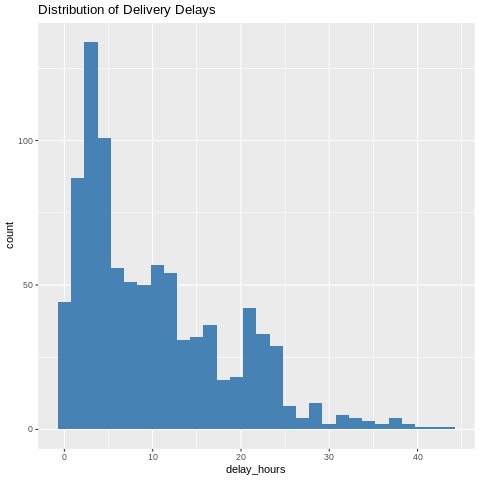

In [ ]:
%%R

ggplot(df, aes(x=delay_hours)) +
  geom_histogram(bins=30, fill="steelblue") +
  ggtitle("Distribution of Delivery Delays")

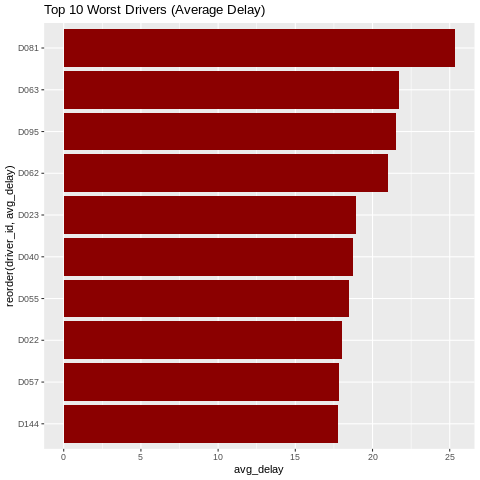

In [ ]:
%%R

ggplot(driver_perf, aes(x=reorder(driver_id, avg_delay), y=avg_delay)) +
  geom_bar(stat="identity", fill="darkred") +
  coord_flip() +
  ggtitle("Top 10 Worst Drivers (Average Delay)")

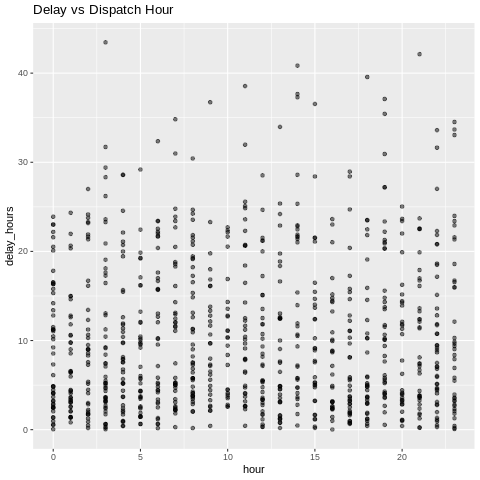

In [ ]:
%%R

ggplot(df, aes(x=hour, y=delay_hours)) +
  geom_point(alpha=0.5) +
  ggtitle("Delay vs Dispatch Hour")